In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import pacf, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import seaborn as sns

In [2]:
df = pd.read_csv('../data/processed/hourly_usage_cleaned.csv').set_index(['datetime', 'client_id'])

In [53]:
# turn into series to that returns a dataframe

def return_pacf_series(group, nlags=168, alpha=0.05):

    array = pacf(group, nlags=nlags)

    return pd.Series(data=array, index=[f'lag_{i}' for i in range(len(array))])


def return_acf_series(group, nlags=168, alpha=0.05):

    array = acf(group, nlags=nlags)

    return pd.Series(data=array, index=[f'lag_{i}' for i in range(len(array))])

In [54]:
# compute the autocorrelation for each client
pacf_series = df.groupby(level='client_id').apply(return_pacf_series)
acf_series = df.groupby(level='client_id').apply(return_acf_series)

In [55]:
# df_auto_corr = df_auto_corr.to_frame().reset_index().pivot(index='client_id', columns='level_1')
pacf_series
pacf_stats = pacf_series.agg(['mean', 'std'])
acf_stats = acf_series.agg(['mean', 'std'])
lags = np.arange(0, len(pacf_stats.columns), 1)

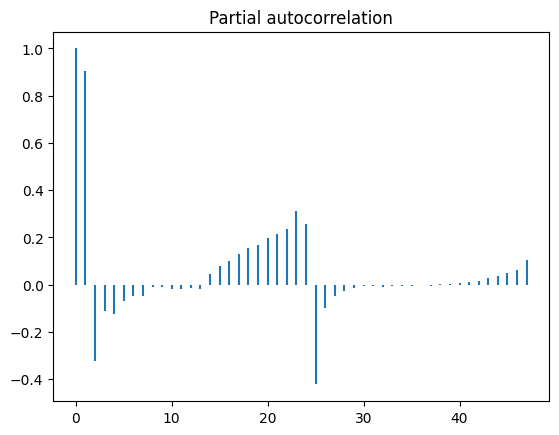

In [ ]:
# plot the average pacf
# plt.vlines(lags, 0, ymax=pacf_stats.iloc[0])
plt.vlines(lags[:48], 0, ymax=pacf_stats.iloc[0, :48])
plt.title('Mean partial autocorrelation function across clients')
plt.show()

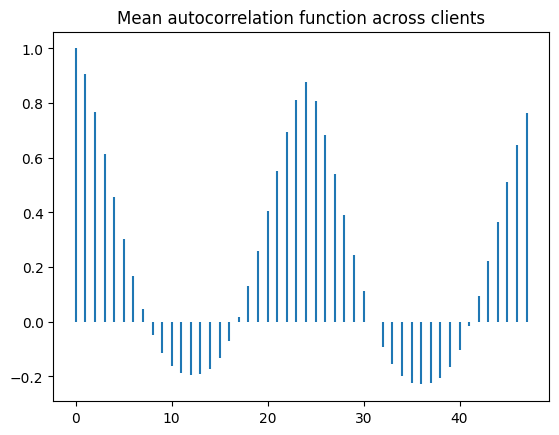

In [67]:
# plt.vlines(lags, 0, ymax=acf_stats.iloc[0])
plt.vlines(lags[:48], 0, ymax=acf_stats.iloc[0, :48])
plt.title('Mean autocorrelation function across clients')
plt.show()

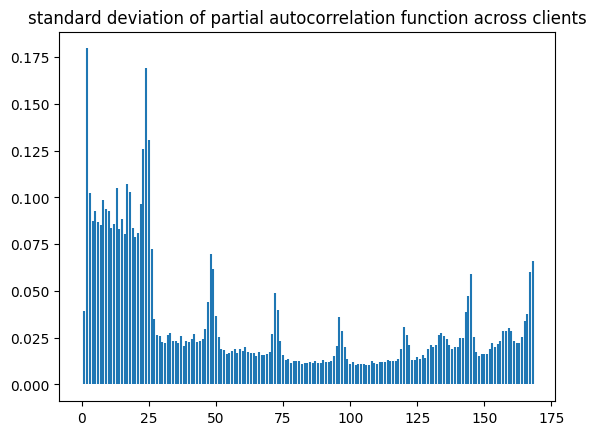

In [68]:
plt.vlines(lags, 0, ymax=pacf_stats.iloc[1])
plt.title('standard deviation of partial autocorrelation function across clients')
plt.show()

In [79]:
df.index.get_level_values('client_id').unique()

Index([  2,   4,   5,   6,   7,   8,   9,  10,  11,  12,
       ...
       360, 361, 363, 364, 365, 366, 367, 368, 369, 370],
      dtype='int64', name='client_id', length=359)

In [ ]:
client_data = df[df.index.get_level_values('client_id') == 361]


test_non_stationary = client_data.values + np.arange(0, len(client_data))
# ADF = adfuller(, maxlag=168)

: 

In [83]:
# print('adf test statistic: ', ADF['adf'])
# print('adf p value: ', ADF.pvalue)


# def flag_non_stationary_client(group):

#     ADF_sta


# ADF stat is less than critical values, so likely stationary
ADF

(np.float64(-2.2237162707026696),
 np.float64(0.19775068358352166),
 168,
 26135,
 {'1%': np.float64(-3.4306002369388464),
  '5%': np.float64(-2.8616505973622957),
  '10%': np.float64(-2.5668288677053908)},
 np.float64(246213.0720216601))

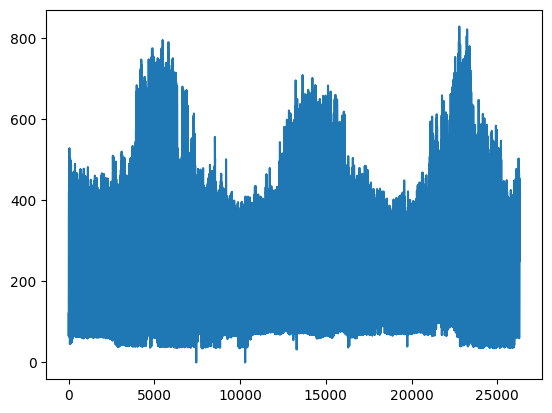

In [88]:
plt.plot(df[df.index.get_level_values('client_id') == 361].values)
plt.show()
